In [ ]:
import os
import sys

sys.path.append("../")
from data import NiiPoint, BaseTfmLibrary as tfm_base, DataTfmLibrary as tfm_data
import json

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
source_dir = "../nnUNet_raw/Dataset/"
target_dir = "../nnUNet_raw/Dataset_normalized/"

os.makedirs(os.path.join(target_dir, "imagesTr"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "labelsTr"), exist_ok=True)

os.makedirs(os.path.join(target_dir, "imagesTs"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "labelsTs"), exist_ok=True)

os.makedirs(os.path.join(target_dir, "imagesVl"), exist_ok=True)
os.makedirs(os.path.join(target_dir, "labelsVl"), exist_ok=True)

def normalize_and_save():
    for train_or_test in ["Tr", "Ts"]:
        images_dir = os.path.join(source_dir, f"images{train_or_test}")
        labels_dir = os.path.join(source_dir, f"labels{train_or_test}")
        
        files = os.listdir(images_dir)
        for file in files:
            print(f"Processing {file}...", end="\r")
            case = file[:9]
            
            ncct_data = NiiPoint.from_path(os.path.join(images_dir, f"{case}_0000.nii.gz"), "cuda")
            cta_data = NiiPoint.from_path(os.path.join(labels_dir, f"{case}_0001.nii.gz"), "cuda")
            
            ncct_norm = tfm_data.ncct_normalization_tfm(ncct_data)
            vess_norm = tfm_data.vessel_normalization_tfm(
                tfm_data.vessel_tfm(ncct_data, cta_data)
            )
            
            ncct_norm.save_to_path(os.path.join(target_dir, f"images{train_or_test}", f"{case}_0000.nii.gz"))
            vess_norm.save_to_path(os.path.join(target_dir, f"labels{train_or_test}", f"{case}_0001.nii.gz"))
            

    dataset_json = {
        "channel_names": {
            "0": "NCCT_norm",
            "1": "VSL_norm"
        },
        "numTraining": len(os.listdir(os.path.join(target_dir, "imagesTr"))),
        "numTest": len(os.listdir(os.path.join(target_dir, "imagesTs"))),
        "file_ending": ".nii.gz",
    }

    with open(os.path.join(target_dir, "dataset.json"), "w") as f:
        json.dump(dataset_json, f, indent=4)
        
normalize_and_save()

<Axes: title={'center': 'Z Slice'}>

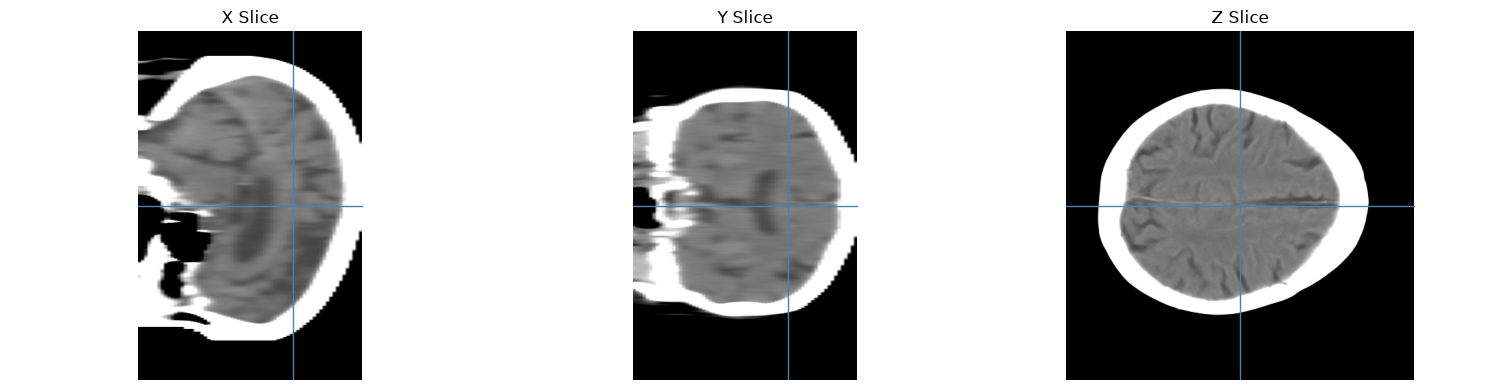

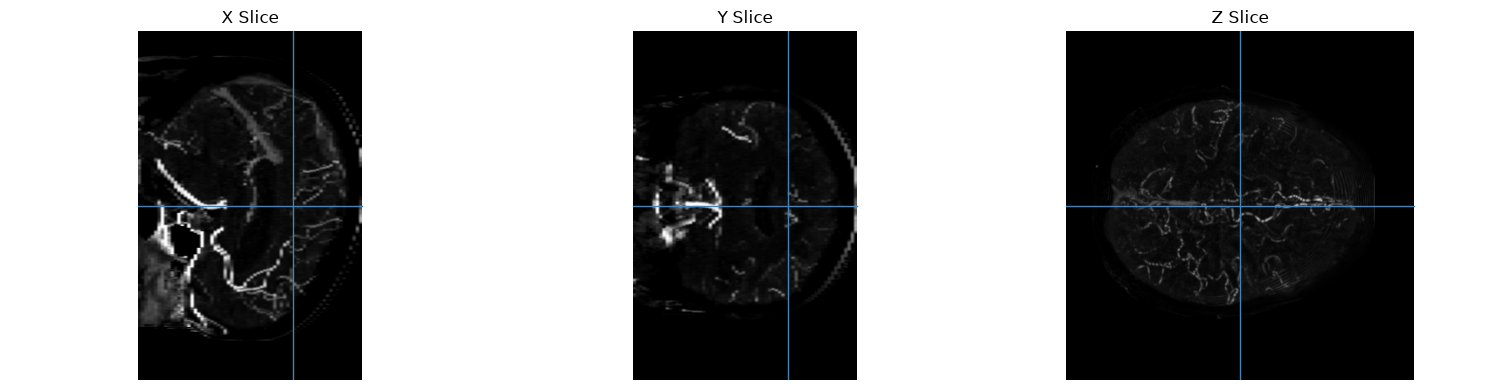

In [12]:
id = 102
id = str(id).zfill(4)
data = NiiPoint.from_path(os.path.join(target_dir, "imagesTr", f"case_{id}_0000.nii.gz"), "cuda")
label = NiiPoint.from_path(os.path.join(target_dir, "labelsTr", f"case_{id}_0001.nii.gz"), "cuda")

data.plot_slices((0.5, 0.5, 0.7), (1, 1, 1), vmin=-1.0, vmax=1.0, cmap="gray")
label.plot_slices((0.5, 0.5, 0.7), (10, 10, 10), vmin=-1.0, vmax=1.0, cmap="gray")
